# Interpolación

### CAPÍTULO 2

**Programación Científica 2026-1 · Universidad Nacional de Colombia**  
mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

In [18]:
#!sudo apt-get update
#!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import matplotlib.pyplot as plt

import matplotlib.colors as mcolors

import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid                          # ← bug 1: sintaxis mezclada
    "grid.color"    : "gray",       # todo debe ir como claves del dict
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Configuración OK


In [ ]:
# 1. Generamos unos datos de prueba (6 puntos aleatorios)
np.random.seed(42)

n_puntos = 6
a = 0
b = 5

x_datos = np.linspace(a, b, n_puntos)
y_datos = np.random.uniform(-2, 2, n_puntos)

# 2. CONSTRUCCIÓN MATRIZ DE VANDERMONDE 
# Inicializamos una matriz de ceros de tamaño (n_puntos, n_puntos)
V_mat = np.zeros((n_puntos, n_puntos))

# Eligimos una base de potencias (x^0, x^1, x^2, ..., x^(n-1))


print("Matriz de Vandermonde:")
print(np.round(V_mat, 2))

# 3. Resolvemos el sistema de ecuaciones lineales V * c = y
coeficientes = np.linalg.solve(V_mat, y_datos)

# 4. Evaluamos el polinomio en un eje x denso para graficar la curva suave
x_continuo = np.linspace(a - a/2, b + b/2, 200)
y_interpolado = np.zeros_like(x_continuo)

# Evaluamos manualmente sumando c_j * x^j
for j in range(n_puntos):
    y_interpolado += coeficientes[j] * (x_continuo**j)

# Graficamos
plt.figure(figsize=(10, 5))
plt.plot(x_datos, y_datos, 'ko', markersize=8, label='Datos Originales', zorder=5)
plt.plot(x_continuo, y_interpolado, 'b-', label='Polinomio Interpolador (Vandermonde)')
plt.title(f'Interpolación con Polinomio de Grado {n_puntos-1}')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Matriz de Vandermonde:
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


LinAlgError: Singular matrix

## Y si hacemos que los datos x sean más "reales" (ej. años)

```python 

x_anios = np.linspace(2000, 2010, 11)
y_anios = np.random.uniform(10, 50, 11)

# Construimos Vandermonde con la base estándar: phi_j(x) = x^j
V_estandar = np.vander(x_anios, ...)

condicion_estandar = np.linalg.cond(V_estandar)

print(f"Condición con base estándar: {condicion_estandar:.2e}")
# ¡el número es gigantesco, la matriz es inútil! 


### Y si intentamos otra base ...

¿Qué pasa si usamos logaritmos?

## Interpolación de Lagrange

* Para un conjunto dado de puntos de datos $(t_i, y_i), i = 1, \dots, n$, las **funciones base de Lagrange** se definen como:
  
  $$\ell_j(t) = \prod_{k=1, k \neq j}^n (t - t_k) \Bigg/ \prod_{k=1, k \neq j}^n (t_j - t_k), \quad j = 1, \dots, n$$

* Para la base de Lagrange,

  $$\ell_j(t_i) = \begin{cases} 1 & \text{si } i = j \\ 0 & \text{si } i \neq j \end{cases}, \quad i, j = 1, \dots, n$$

  por lo que la matriz del sistema lineal $Ax = y$ es la matriz identidad.

* Por lo tanto, el polinomio de Lagrange que interpola los puntos de datos $(t_i, y_i)$ está dado por:

  $$p_{n-1}(t) = y_1\ell_1(t) + y_2\ell_2(t) + \dots + y_n\ell_n(t)$$


ValueError: x, y, and format string must not be None

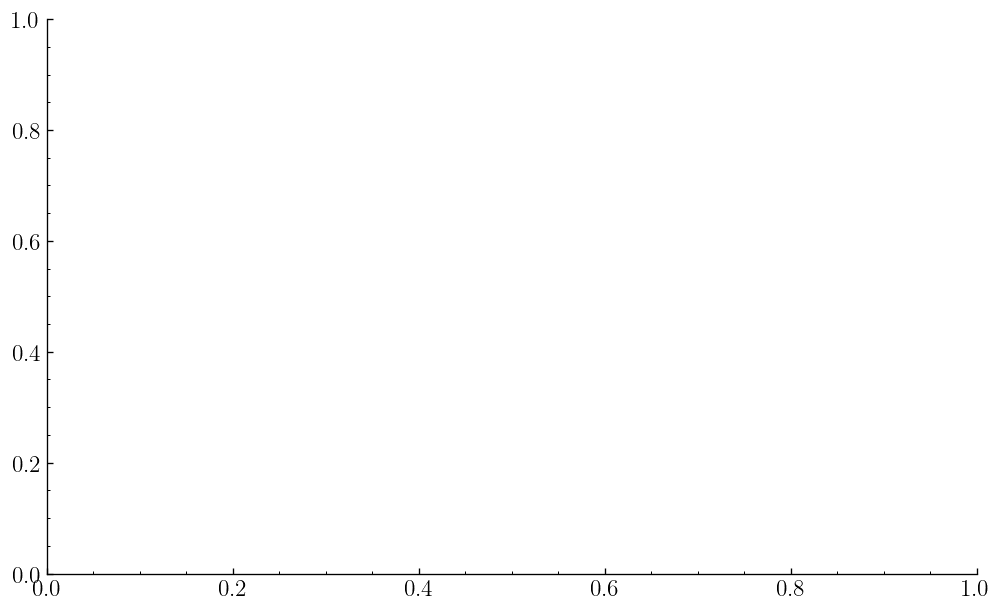

In [ ]:
def base_lagrange(x_datos, i, x_continuo):
    """
    Calcula la i-ésima función base de Lagrange evaluada en un arreglo x_continuo.
    """
    

# 1. Definimos los nodos de interpolación (puntos x)
# Puedes cambiar estos valores para ver cómo se deforman las campanas
x_nodos = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
n_nodos = len(x_nodos)

# 2. Creamos un eje x denso para que la curva se vea suave
x_cont = np.linspace(-0.1, 1.1, 50)

# 3. Configuramos la gráfica
plt.figure(figsize=(10, 6))

color = ['c*-', 'r+-', 'gd-', 'b--', 'm.-']  # Colores para los puntos clave
# Calculamos y graficamos cada función base L_i
for i in range(n_nodos):
    y_base = base_lagrange(x_nodos, i, x_cont)
    
    # Graficamos la curva de L_i
    plt.plot(x_cont, y_base, color[i], label=f'$L_{i}(x)$')
    
# 4. Detalles visuales
plt.axhline(0, color='black', linewidth=1) # Eje X

plt.title('Funciones Base de Lagrange para 5 nodos', fontsize=14, fontweight='bold')
plt.xlabel('$x$')
plt.ylabel('$L_i(x)$')
plt.legend()
plt.grid(True, alpha=0.6)

# Limitamos un poco el eje Y para que los extremos de los polinomios no dominen la vista
plt.ylim(-1.5, 1.5) 

plt.show()

## El fenómeno de Runge

Ocurre al interpolar funciones con polinomios de alto grado utilizando puntos equiespaciados.

**El Problema:** Aparecen oscilaciones violentas cerca de los extremos del intervalo.

**Causa Numérica:** Los polinomios globales son "demasiado sensibles/explosivos" a los bordes.

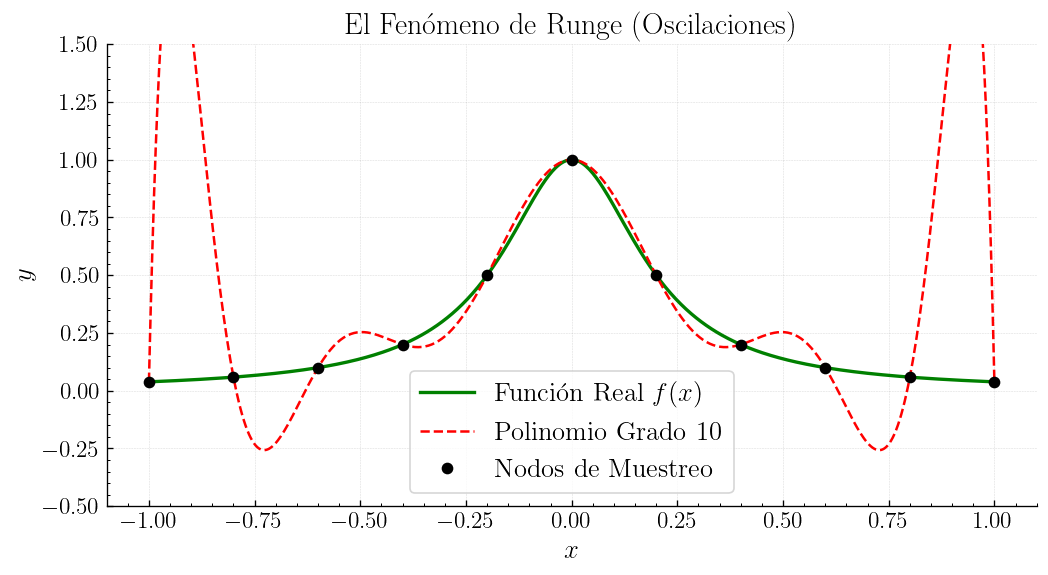

In [32]:
import scipy

# 1. Definimos la función de Runge original
def runge(x):
    return 1 / (1 + 25 * x**2)

# Eje X continuo para la función real
x_real = np.linspace(-1, 1, 500)
y_real = runge(x_real)

# 2. Tomamos 11 puntos equiespaciados (esto generará un polinomio de grado 10)
n_puntos = 11
x_nodos = np.linspace(-1, 1, n_puntos)
y_nodos = runge(x_nodos)

# 3. Ajustamos el polinomio 
poly = scipy.interpolate.lagrange(x_nodos, y_nodos)

y_interpolado = poly(x_real)

# 4. Graficamos el desastre
plt.figure(figsize=(10, 5))
plt.plot(x_real, y_real, 'g-', label='Función Real $f(x)$', linewidth=2)
plt.plot(x_real, y_interpolado, 'r--', label=f'Polinomio Grado {n_puntos-1}')
plt.plot(x_nodos, y_nodos, 'ko', label='Nodos de Muestreo')

plt.title('El Fenómeno de Runge (Oscilaciones)')
plt.ylim(-0.5, 1.5)
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlabel('$x$')
plt.ylabel('$y$')

plt.show()

## El Aliasing

Distorsión que sucede cuando una señal continua se muestrea a una frecuencia insuficiente para su reconstrucción.

**Pérdida de Información:** Las frecuencias altas "se disfrazan" de frecuencias bajas.

**Límite de Nyquist:** Debes muestrear al menos al doble de la frecuencia máxima.

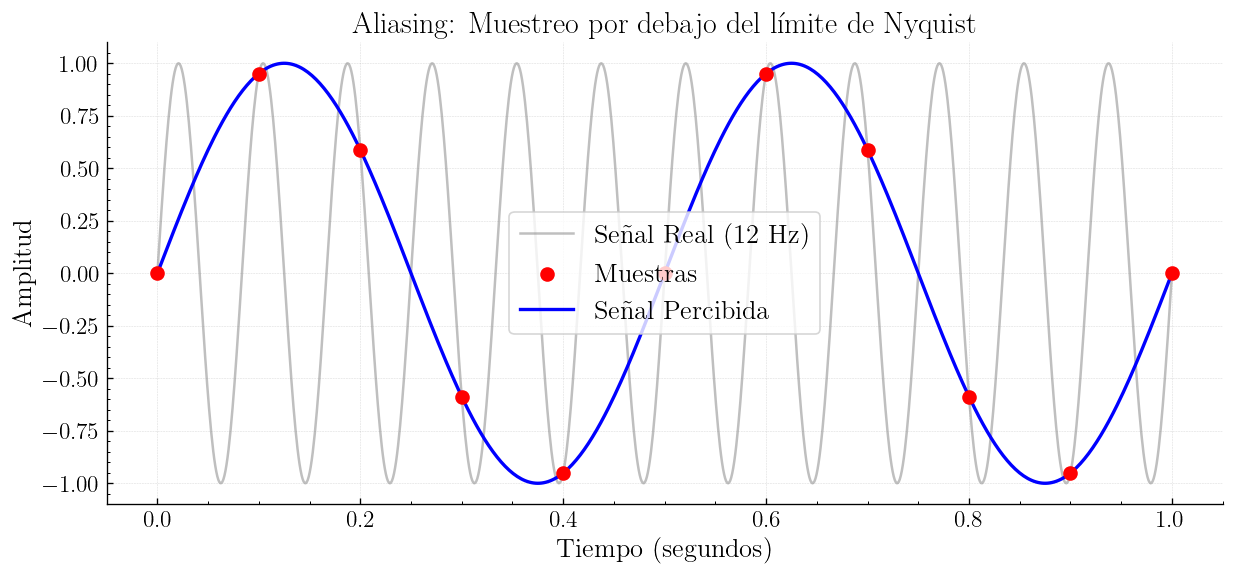

In [33]:
# 1. Señal original de Alta Frecuencia (12 Hz)
frecuencia_senal = 12  # 12 ciclos por segundo
t_real = np.linspace(0, 1, 1000)
y_real = np.sin(2 * np.pi * frecuencia_senal * t_real)

# 2. Muestreo deficiente (Frecuencia de muestreo = 10 Hz)
# Según Nyquist, para ver 12Hz deberíamos muestrear a MAS de 24Hz. ¡10Hz es un error!
frecuencia_muestreo = 10 
t_muestreo = np.arange(0, 1 + 1/frecuencia_muestreo, 1/frecuencia_muestreo)
y_muestreo = np.sin(2 * np.pi * frecuencia_senal * t_muestreo)

# Interpolamos linealmente los puntos mal muestreados para ver qué entiende la computadora
t_interp = np.linspace(0, 1, 500)
y_falsa = np.sin(2 * np.pi * (frecuencia_senal - frecuencia_muestreo) * t_interp)

# 3. Graficamos
plt.figure(figsize=(12, 5))
plt.plot(t_real, y_real, 'gray', alpha=0.5, label='Señal Real (12 Hz)')
plt.scatter(t_muestreo, y_muestreo, color='red', s=60, zorder=5, label='Muestras')
plt.plot(t_interp, y_falsa, 'b-', linewidth=2, label='Señal Percibida')

plt.title('Aliasing: Muestreo por debajo del límite de Nyquist')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Amplitud')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()